In [2]:
import pandas as pd

In [4]:
# 1. Load the data
df = pd.read_csv(r"C:\Users\user\Downloads\marketing_campaign_data.csv")
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,3,4,0,0,0,0,0,0,0,Spain
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,2,3,0,0,0,0,0,0,0,Spain
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,6,3,0,0,0,0,0,0,0,Australia
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,11,4,0,0,0,0,0,0,0,Spain
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,3,6,0,0,0,0,0,0,0,Canada
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55995,2485439,1985,Graduation,Married,32533.4,0,0,2013-04-05,99,8,...,6,8,0,0,0,0,0,0,0,Australia
55996,9202496,1992,Basic,Single,70496.3,0,1,2013-01-31,9,835,...,8,4,0,0,0,0,0,0,0,Germany
55997,14677746,1950,Graduation,Together,21072.0,1,0,2013-06-25,24,0,...,0,3,0,0,0,0,0,1,0,Saudi Arabia
55998,3843719,1976,Graduation,Together,64218.1,0,0,2014-05-12,81,8,...,1,8,0,0,0,0,0,0,0,Saudi Arabia


Data Cleaning.

In [7]:
# 2. Fill Missing Values (use the middle value)
# This ensures calculations like 'Total Spend' don't break.
df['Income'] = df['Income'].fillna(df['Income'].median())

In [8]:
# 3. Fix Date Format 
# Converting the text date into a real Python date
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

In [9]:
# 4. Remove obvious errors (Basic Outliers)
# Removing anyone born before 1900 or with Income above 200k
df = df[df['Year_Birth'] > 1900]
df = df[df['Income'] < 200000]

In [10]:
# 5. Create the required "New" columns
df['Age'] = 2025 - df['Year_Birth']
df['Children'] = df['Kidhome'] + df['Teenhome']
df['Total_Spend'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
df['Total_Purchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases'] + df['NumDealsPurchases']
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Income_Bin,Age,Children,Total_Spend,Total_Purchases
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,0,0,0,0,Spain,Mid,40,1,69,13
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,0,0,0,0,Spain,Low,50,2,39,4
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,0,0,0,0,Australia,High,47,0,1512,12
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,0,0,0,0,Spain,Mid,49,1,478,16
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,0,0,0,0,Canada,Mid,44,2,330,9


In [11]:
# 6. Create the 'Segment' column (This fixes the KeyError)
# Logic: We categorize customers based on the project requirements
spend_90th = df['Total_Spend'].quantile(0.9)

def get_segment(row):
    if row['Total_Spend'] > spend_90th: return 'High Spender'
    if row['Income'] > 75000: return 'High Income'
    if row['Response'] == 1: return 'Campaign Responder'
    if row['Age'] < 30: return 'Young Customer'
    if row['NumWebVisitsMonth'] > 5: return 'High Web Engagement'
    if row['Children'] > 0: return 'Family Customer'
    return 'Standard'

df['Segment'] = df.apply(get_segment, axis=1)

In [12]:
# 7. Simplify Categories (Great for Bivariate analysis)
# Grouping complex marital statuses into just two simple groups
df['Marital_Status'] = df['Marital_Status'].replace(['Married', 'Together'], 'Partner')
df['Marital_Status'] = df['Marital_Status'].replace(['Absurd', 'Widow', 'YOLO', 'Divorced', 'Alone'], 'Single')
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Response,Complain,Country,Income_Bin,Age,Children,Total_Spend,Total_Purchases,Segment
0,342199,1985,Graduation,Partner,59011.7,1,0,2012-11-17,3,0,...,0,0,0,Spain,Mid,40,1,69,13,Family Customer
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,0,0,0,Spain,Low,50,2,39,4,Family Customer
2,13664263,1978,Graduation,Partner,98584.6,0,0,2014-01-11,99,920,...,0,0,0,Australia,High,47,0,1512,12,High Income
3,16164787,1976,Graduation,Partner,74031.5,1,0,2014-06-18,47,265,...,0,0,0,Spain,Mid,49,1,478,16,Family Customer
4,15815139,1981,Graduation,Single,52784.2,1,1,2014-05-20,0,30,...,0,0,0,Canada,Mid,44,2,330,9,High Web Engagement


In [13]:
# 6. Income Categories 
df['Income_Bin'] = pd.qcut(df['Income'], q=3, labels=['Low', 'Mid', 'High'])

In [14]:
print(df[['Age', 'Total_Spend', 'Marital_Status','Segment','Income_Bin']].head())

   Age  Total_Spend Marital_Status              Segment Income_Bin
0   40           69        Partner      Family Customer        Mid
1   50           39         Single      Family Customer        Low
2   47         1512        Partner          High Income       High
3   49          478        Partner      Family Customer        Mid
4   44          330         Single  High Web Engagement        Mid


In [15]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Response,Complain,Country,Income_Bin,Age,Children,Total_Spend,Total_Purchases,Segment
0,342199,1985,Graduation,Partner,59011.7,1,0,2012-11-17,3,0,...,0,0,0,Spain,Mid,40,1,69,13,Family Customer
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,0,0,0,Spain,Low,50,2,39,4,Family Customer
2,13664263,1978,Graduation,Partner,98584.6,0,0,2014-01-11,99,920,...,0,0,0,Australia,High,47,0,1512,12,High Income
3,16164787,1976,Graduation,Partner,74031.5,1,0,2014-06-18,47,265,...,0,0,0,Spain,Mid,49,1,478,16,Family Customer
4,15815139,1981,Graduation,Single,52784.2,1,1,2014-05-20,0,30,...,0,0,0,Canada,Mid,44,2,330,9,High Web Engagement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55995,2485439,1985,Graduation,Partner,32533.4,0,0,2013-04-05,99,8,...,0,0,0,Australia,Low,40,0,53,19,High Web Engagement
55996,9202496,1992,Basic,Single,70496.3,0,1,2013-01-31,9,835,...,0,0,0,Germany,Mid,33,1,924,12,Family Customer
55997,14677746,1950,Graduation,Partner,21072.0,1,0,2013-06-25,24,0,...,0,1,0,Saudi Arabia,Low,75,1,608,5,Campaign Responder
55998,3843719,1976,Graduation,Partner,64218.1,0,0,2014-05-12,81,8,...,0,0,0,Saudi Arabia,Mid,49,0,69,8,High Web Engagement


Exploratory Data Analysis (EDA).

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Set the visual style
sns.set_theme(style="whitegrid")

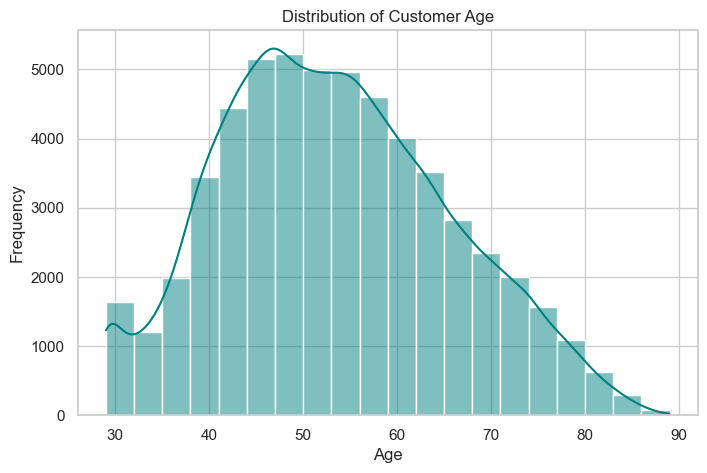

In [18]:
# --- SECTION 1: UNIVARIATE ANALYSIS  ---
# Objective: Understand the distribution of individual key variables.

# A. Distribution of Age
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='teal')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

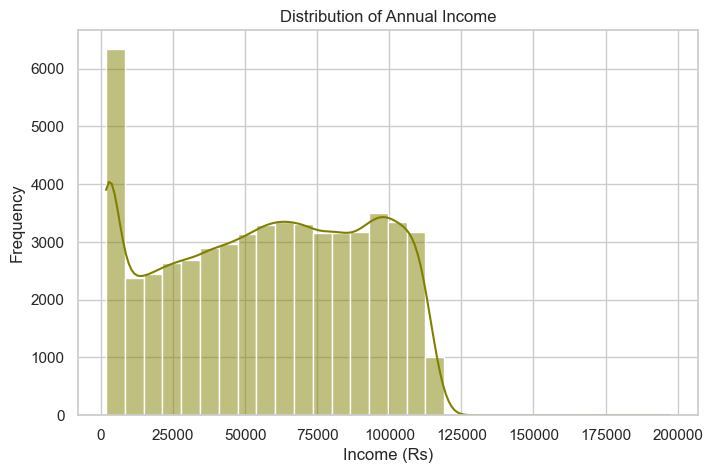

In [19]:
# B. Distribution of Income
plt.figure(figsize=(8, 5))
sns.histplot(df['Income'], bins=30, kde=True, color='olive')
plt.title('Distribution of Annual Income')
plt.xlabel('Income (Rs)')
plt.ylabel('Frequency')
plt.show()

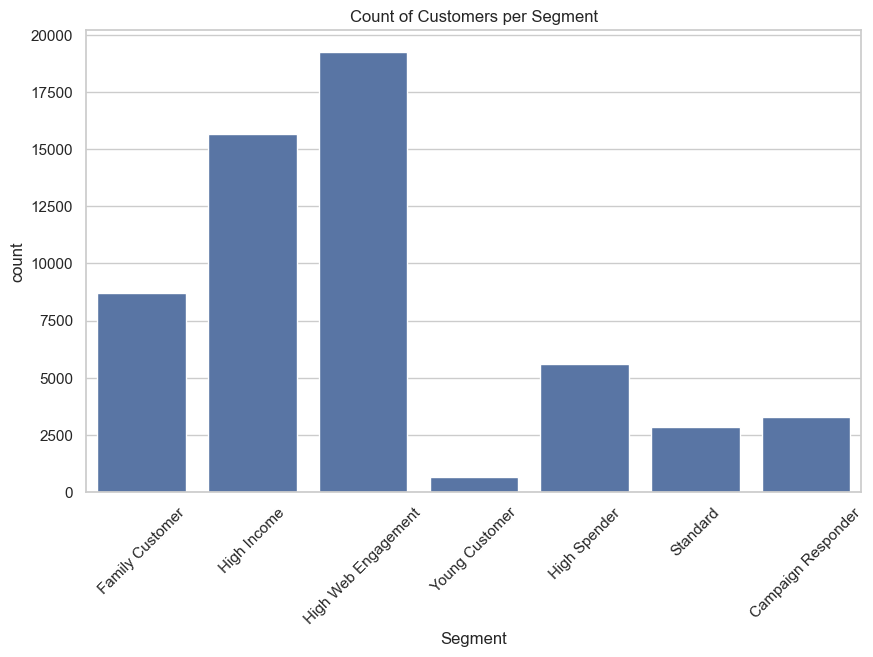

In [20]:
# C. Customer Segments (The column we created during cleaning)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Segment')
plt.title('Count of Customers per Segment')
plt.xticks(rotation=45)
plt.show()

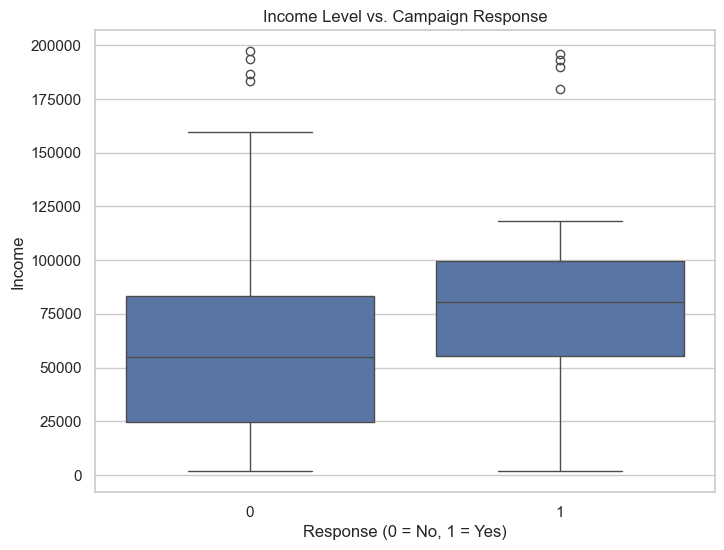

In [21]:
# --- SECTION 2: BIVARIATE ANALYSIS [cite: 30, 31] ---
# Objective: Explore how variables relate to each other, specifically targeting the 'Response'.

# A. Income vs. Campaign Response
# Does a higher income lead to a higher likelihood of accepting the campaign?
plt.figure(figsize=(8, 6))
sns.boxplot(x='Response', y='Income', data=df)
plt.title('Income Level vs. Campaign Response')
plt.xlabel('Response (0 = No, 1 = Yes)')
plt.ylabel('Income')
plt.show()

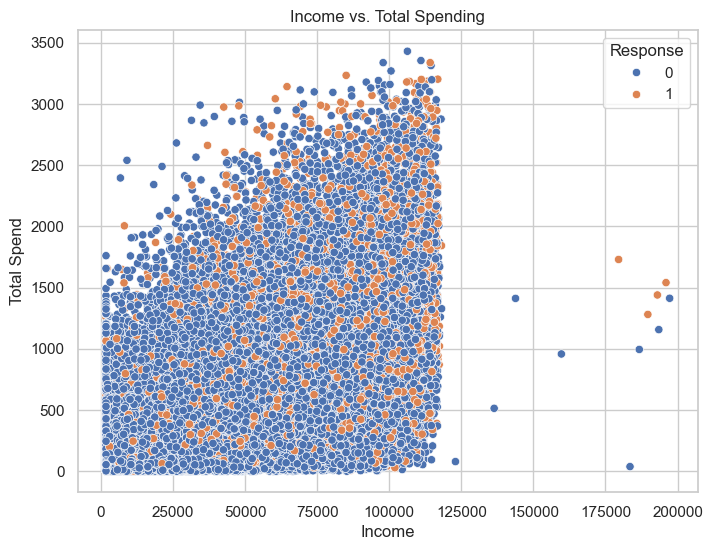

In [22]:
# B. Total Spend vs. Income
# Checking the correlation between wealth and spending behavior.
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Income', y='Total_Spend', data=df, hue='Response')
plt.title('Income vs. Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spend')
plt.show()

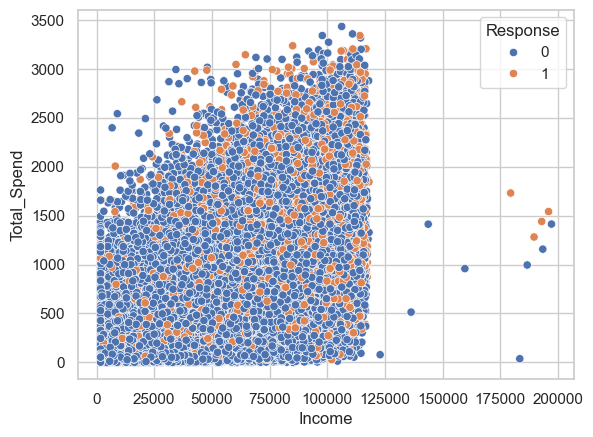

In [23]:
# Simple Scatter Plot
sns.scatterplot(data=df, x='Income', y='Total_Spend', hue='Response')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_30932\3007245464.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Marital_Status', y='Response', data=df,ci=None,palette='pastel')
C:\Users\user\AppData\Local\Temp\ipykernel_30932\3007245464.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Marital_Status', y='Response', data=df,ci=None,palette='pastel')


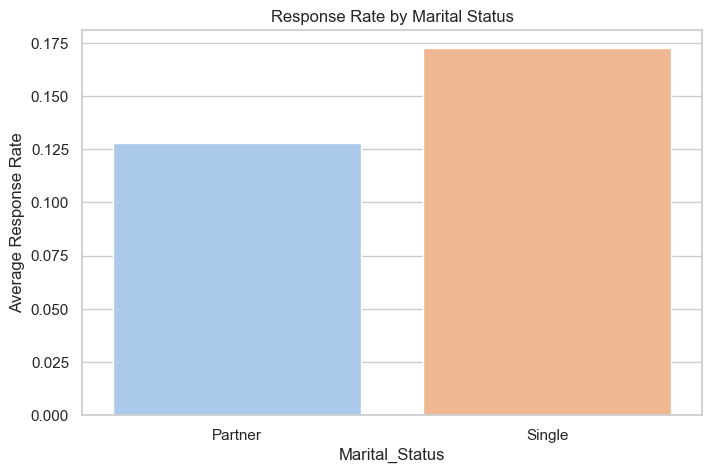

In [24]:
# C. Response Rate by Marital Status (Simplified)
# Are partnered individuals more or less likely to respond than singles?
plt.figure(figsize=(8, 5))
sns.barplot(x='Marital_Status', y='Response', data=df,ci=None,palette='pastel')
plt.title('Response Rate by Marital Status')
plt.ylabel('Average Response Rate')
plt.show()

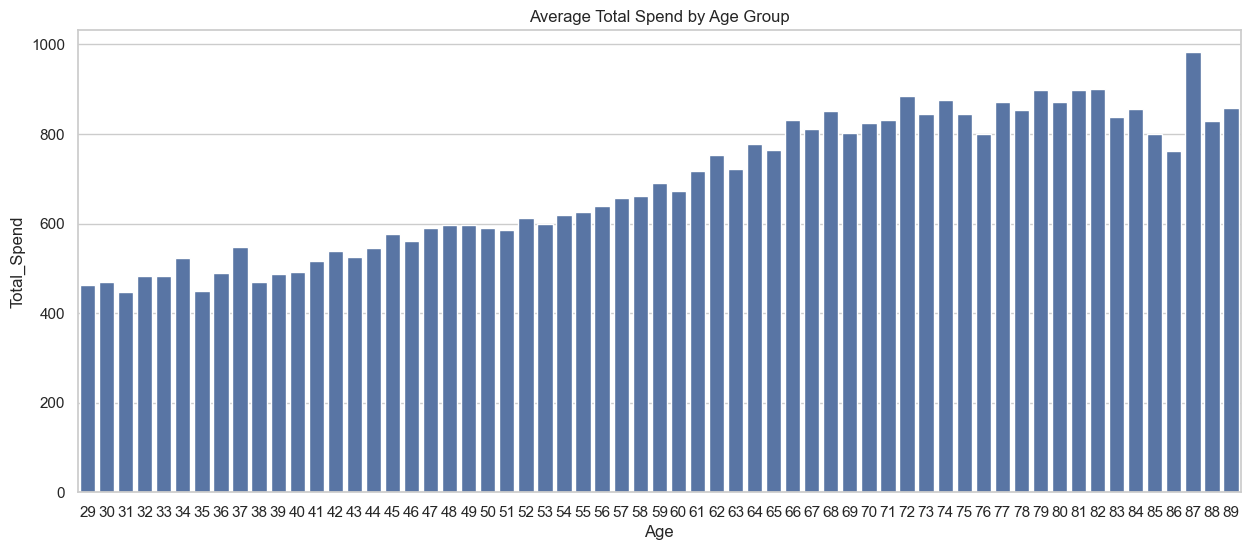

In [25]:
# D. Spending Patterns across Products by Age Group [cite: 14]
# We use the Age_Bin created during cleaning to see spending trends.
age_spending = df.groupby('Age')['Total_Spend'].mean().reset_index()
plt.figure(figsize=(15,6))
sns.barplot(x='Age', y='Total_Spend', data=age_spending)
plt.title('Average Total Spend by Age Group')
plt.show()

Multivarirnt Ananlysis

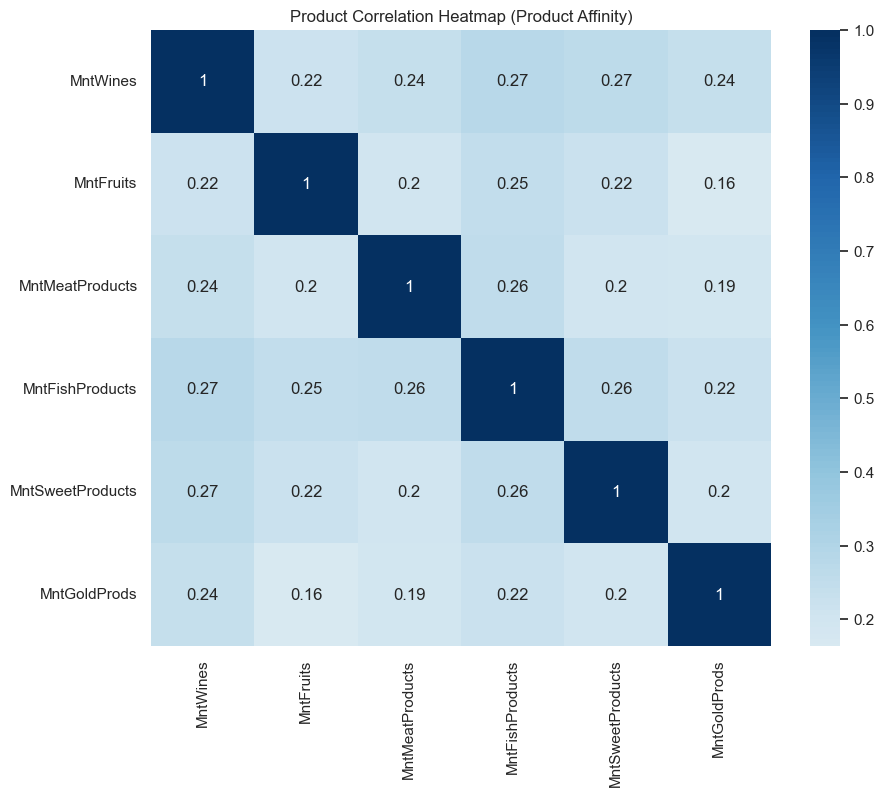

In [26]:
# Product Affinity: Which products are bought together?
# Use a heatmap to see correlations between product categories
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
plt.figure(figsize=(10, 8))
sns.heatmap(df[product_cols].corr(), annot=True, cmap='RdBu', center=0)
plt.title('Product Correlation Heatmap (Product Affinity)')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_30932\4172316279.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_response.values, y=segment_response.index, palette='magma')


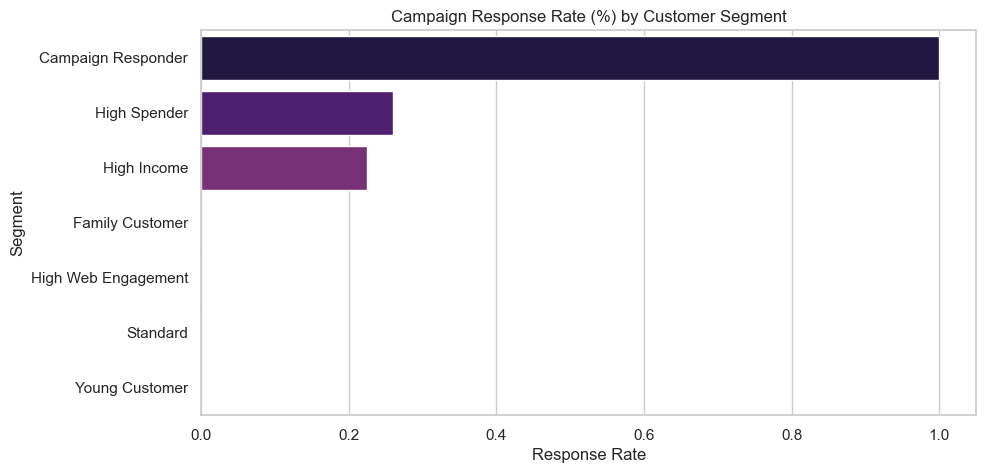

In [27]:
# Campaign Success Rate by Segment 
# Identify the "Ideal Target Customer"
segment_response = df.groupby('Segment')['Response'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=segment_response.values, y=segment_response.index, palette='magma')
plt.title('Campaign Response Rate (%) by Customer Segment')
plt.xlabel('Response Rate')
plt.show()

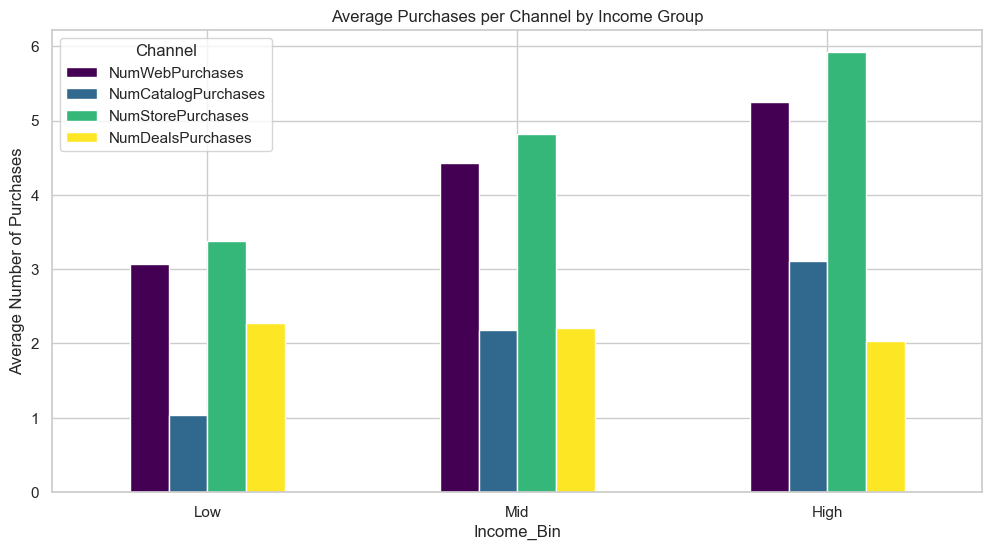

In [31]:
# Channel Preference by Income Band 
# Compare where High vs Low income customers shop
channels = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']
channel_data = df.groupby('Income_Bin')[channels].mean()
channel_data.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Average Purchases per Channel by Income Group')
plt.ylabel('Average Number of Purchases')
plt.legend(title='Channel')
plt.xticks(rotation=0)
plt.show()

In [32]:
# SAVE CLEANED DATA
df.to_csv('marketing_project_cleaned.csv', index=False)
print("Done! Cleaned data saved.")

Done! Cleaned data saved.
